In [1]:
import gc
import math
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.nn.utils import clip_grad_norm_

from torch.utils.data import DataLoader, Subset, TensorDataset, random_split
from torchmetrics.image.fid import FrechetInceptionDistance

import torchvision
from torchvision import transforms as T

from tqdm import tqdm
import matplotlib.pyplot as plt


device = 'cuda' if torch.cuda.is_available() else 'cpu'

# transforms:  3×32×32 RGB  →  flat 3072-vector in [0,1]
to_flat = T.Compose([
    T.ToTensor(),                       # [3,32,32], float32 ∈ [0,1]
    T.Lambda(lambda x: x.view(-1))      # flatten to [3072]
])

#  full CIFAR-10 training set  (50 000 images)
cifar100 = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=to_flat
)
    
train_frac   = 0.90
total         = len(cifar100)                    # 60 000
train_size   = int(total * train_frac)      # 12 000
torch.manual_seed(0)                          # seed
rdid = torch.randperm(total)
train_idx = rdid[:train_size]
test_idx  = rdid[train_size:]
cifar10_train  = Subset(cifar100, train_idx)
cifar10_test  = Subset(cifar100, test_idx)

#  feature dimension   (used later by model)
D = 3*32*32     # 3072


# Plot original and noised
def show(imgs, title=None):
    imgs = torch.stack(imgs).reshape(-1, 3, 32, 32)
    grid = torchvision.utils.make_grid(imgs, nrow=len(imgs))
    plt.figure(figsize=(10, 2))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.show()


Files already downloaded and verified


In [2]:


### Training Transformer Implementation


class WitnessScoreCrossAttention(nn.Module):
    """∇ log q_t(x) via K trainable witnesses W."""
    def __init__(self, init_W: torch.Tensor):          # init_W float32 [K,D]
        super().__init__()
        self.W = nn.Parameter(init_W.float())          # keep FP32 for scaler
        d = init_W.shape[1]
        self.Q = nn.Parameter(torch.ones(D),requires_grad=True)
        self.V = nn.Parameter(torch.ones(D),requires_grad=True)


    def forward(self, x, t):                           # x[B,D]  t:scalar
        W = self.W.to(x.dtype)                         # fp16/bf16 copy
        Q = self.Q
        Qx = x * (self.Q)[None,:]
        QW = W * (self.Q)[None,:]
        Vx = x * (self.V)[None,:]**2
        VW = W * (self.V)[None,:]**2
        x2 = (Qx**2).sum(1, keepdim=True)               # [B,1]
        W2 = (QW**2).sum(1)                             # [K]
        dist2 = x2 + W2 - 2 * (Qx @ QW.T)                # [B,K]
        w  = torch.softmax(-0.5 * dist2 / t , dim=1)    # [B,K]
        expW = w @ VW                                   # [B,D]
        return -(Vx - expW) / t                         # [B,D]

def init_witnesses(train_tensor: torch.Tensor,
                   K: int = 1000,
                   seed: int | None = None) -> torch.Tensor:
    if seed is not None:
        torch.manual_seed(seed)

    N = train_tensor.size(0)
    if K > N:
        raise ValueError(f"K={K} exceeds dataset size N={N}")

    # sample K unique indices without replacement
    idx = torch.randperm(N, device=train_tensor.device)[:K]

    # gather the corresponding data points
    W0 = train_tensor[idx].clone()          # [K, D]
    return W0.float()                       # ensure fp32
class SixStepDenoiser_multiple(nn.Module):
    def __init__(self, D, K, train_tensor, t_start=1.0, t_end=1e-3):
        super().__init__()

        # six independent witness layers
        self.scores = nn.ModuleList([
            WitnessScoreCrossAttention(init_witnesses(train_tensor, K, seed=i))
            for i in range(6)
        ])

        L = 6
        r = (t_end / t_start) ** (1 / (L - 1))
        t_lin = t_start * r ** torch.arange(L, device=device)   
        dt_lin = torch.cat([t_lin[1:] - t_lin[:-1], t_lin[-1:]-t_lin[-2:-1]])

        self.t_raw  = nn.Parameter(torch.log(torch.exp(t_lin)  - 1))
        self.dt_raw = nn.Parameter(torch.log(torch.exp(-dt_lin) - 1))

    def times_and_steps(self):
        t  = F.softplus(self.t_raw)
        dt = -F.softplus(self.dt_raw)
        return t, dt

    def forward(self, x0):
        t, dt = self.times_and_steps()
        x = x0; traj=[x.clone()]
        for i in range(6):
            score = self.scores[i](x, t[i])       # layer-specific witnesses
            x = x - t[i] * dt[i] * score
            traj.append(x.clone())
        return x, traj

class SixStepDenoiser_multiple(nn.Module):
    def __init__(self, D, K, H, train_tensor, t_start=1.0, t_end=1e-3):
        super().__init__()

        #  six independent witness layers
        self.scores = nn.ModuleList([
            nn.ModuleList([WitnessScoreCrossAttention(init_witnesses(train_tensor, K, seed=i)) for j in range(H)])
            for i in range(6)
        ])
        #  schedule parameters (unchanged)
        L = 6
        r = (t_end / t_start) ** (1 / (L - 1))
        t_lin = t_start * r ** torch.arange(L, device=device)   
        dt_lin = torch.cat([t_lin[1:] - t_lin[:-1], t_lin[-1:]-t_lin[-2:-1]])
        self.t_raw  = nn.Parameter((torch.log(torch.exp(t_lin)  - 1))[:,None].repeat(1,H))
        self.dt_raw = nn.Parameter((torch.log(torch.exp(-dt_lin/4)  - 1))[:,None].repeat(1,H))
        self.H = H

    def times_and_steps(self):
        t  = F.softplus(self.t_raw)
        dt = -F.softplus(self.dt_raw)
        return t, dt

    def forward(self, x0):
        t, dt = self.times_and_steps()
        x = x0; traj=[x.clone()]
        for i in range(6):
            deltax = torch.zeros_like(x)
            for h in range(self.H):
                score = self.scores[i][h](x, t[i,h])       # layer-specific witnesses
                deltax = deltax - t[i][h] * dt[i,h] * score
            x = x + deltax
            traj.append(x.clone())
        return x, traj

In [3]:
# RMSE vs # witnesses • CIFAR-10 • anisotropic models 
#  Prints RMSE for each model and shows the plot

import gc, math, time, torch, matplotlib.pyplot as plt
from pathlib import Path
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR


for v in list(globals().values()):
    if isinstance(v, torch.nn.Module):
        del v
gc.collect();  torch.cuda.empty_cache()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# plotting details: editable constants
epochs_baseline = 250          
epochs_witness  = 250         
witness_grid    = [20,40,100,200,400,800,1000]   
noise_std       = 1.0

CKPT_DIR = Path('new_Stein_models_CIFAR10')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# DataLoaders (identical settings as above)
to_flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])

cifar10 = torchvision.datasets.CIFAR10('./data', train=True,
                                       download=True, transform=to_flat)
data_tensor  = torch.stack([x.to(device) for x, _ in cifar10])
label_tensor = torch.tensor([y for _, y in cifar10], device=device)
ds_on_dev    = TensorDataset(data_tensor, label_tensor)

n_total = len(ds_on_dev)
n_train = int(0.9 * n_total)
n_test  = n_total - n_train
train_ds, test_ds = random_split(ds_on_dev, [n_train, n_test],
                                 generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=1000,
                          shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=1000,
                          shuffle=True, drop_last=True)

train_tensor = torch.stack([d[0] for d in train_ds]).float().to(device)
D = 3 * 32 * 32


def train(model, *, epochs, train_witness, tag=''):
    """Matches original training loop: GradScaler + cosine LR."""
    params = (model.parameters() if train_witness else
              [p for n, p in model.named_parameters()
                 if ('t_raw' in n or 'dt_raw' in n)])

    opt  = torch.optim.Adam(params, lr=1e-1, betas=(0.9, 0.9))
    sch  = CosineAnnealingLR(opt, T_max=epochs * len(train_loader),
                             eta_min=1e-3)
    scaler = GradScaler()
    every  = max(1, epochs // 5)
    t0_all = time.time()

    for ep in range(epochs):
        run = 0.0
        model.train()
        for clean, _ in train_loader:
            clean = clean.to(device)
            noisy = clean + noise_std * torch.randn_like(clean)

            recon, _ = model(noisy)                # no autocast in train loop
            loss = F.mse_loss(recon, clean)

            opt.zero_grad()
            scaler.scale(loss).backward()
            # clip_grad_norm_(model.parameters(), 1.0)   # keep disabled
            scaler.step(opt); scaler.update(); sch.step()
            run += loss.item()

        if (ep + 1) % every == 0 or ep in (0, epochs-1):
            print(f'[{tag}] ep {ep+1:03d}/{epochs}  '
                  f'MSE {run/len(train_loader):.3e}  '
                  f'{(time.time()-t0_all)/60:4.1f} min')

@torch.no_grad()
def rmse(model):
    se, n = 0.0, 0
    model.eval()
    for clean, _ in test_loader:
        clean = clean.to(device)
        noisy = clean + noise_std * torch.randn_like(clean)
        with autocast(dtype=torch.float16):
            recon, _ = model(noisy)
        se += F.mse_loss(recon, clean, reduction='sum').item()
        n  += clean.size(0)
    return math.sqrt(se / n)

#  baseline (K = N) 
K_full  = train_tensor.size(0)
base_ck = CKPT_DIR / f'baseline_fullK_ep{epochs_baseline}.pth'

if base_ck.exists():
    print('⤴ loading CIFAR-10 baseline …')
    baseline = torch.load(base_ck, map_location=device)
else:
    print('⧗ training CIFAR-10 baseline …')
    baseline = SixStepDenoiser_multiple(D=D, K=K_full, H=1,
                                        train_tensor=train_tensor,
                                        t_start=10, t_end=1).to(device)
    shared_W = torch.nn.Parameter(train_tensor.half(), requires_grad=False)
    for lyr in baseline.scores:
        lyr[0].W = shared_W
    train(baseline, epochs=epochs_baseline,
          train_witness=False, tag='BASE')
    torch.save(baseline, base_ck)

baseline_rmse = rmse(baseline)
print(f'Baseline RMSE = {baseline_rmse:.4e}')

#  witness sweep 
rmse_vals = []
for K in witness_grid:
    ck = CKPT_DIR / f'witness_K{K}_ep{epochs_witness}.pth'
    if ck.exists():
        print(f'⤴ loading K={K} …')
        mdl = torch.load(ck, map_location=device)
    else:
        print(f'⧗ training K={K} for {epochs_witness} epochs …')
        mdl = SixStepDenoiser_multiple(D=D, K=K, H=1,
                                       train_tensor=train_tensor,
                                       t_start=10, t_end=1).to(device)
        train(mdl, epochs=epochs_witness,
              train_witness=True, tag=f'K={K}')
        torch.save(mdl, ck)

    r = rmse(mdl); rmse_vals.append(r)
    print(f'   ↳ test-set RMSE = {r:.4e}')
    del mdl; gc.collect(); torch.cuda.empty_cache()

#  plot 
plt.figure(figsize=(7,4))
plt.plot(witness_grid, rmse_vals, marker='o',
         label=f'K witnesses (ep {epochs_witness})')
plt.axhline(baseline_rmse, ls='--',
            label=f'baseline full data (ep {epochs_baseline})')
plt.xscale('log')
plt.xlabel('number of witnesses K (log scale)')
plt.ylabel('RMSE')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()


Files already downloaded and verified
⧗ training CIFAR-10 baseline …
[BASE] ep 001/250  MSE 6.591e-03   0.6 min


KeyboardInterrupt: 

⤴ loading MNIST baseline …
Baseline RMSE = 1.5225e+01
⤴ loading K=20 …
   ↳ test-set RMSE = 5.7807e+00
⤴ loading K=40 …
   ↳ test-set RMSE = 5.6066e+00
⤴ loading K=100 …
   ↳ test-set RMSE = 5.4034e+00
⤴ loading K=200 …
   ↳ test-set RMSE = 5.2726e+00
⤴ loading K=400 …
   ↳ test-set RMSE = 5.1441e+00
⤴ loading K=800 …
   ↳ test-set RMSE = 5.0030e+00
⤴ loading K=1000 …
   ↳ test-set RMSE = 4.9668e+00


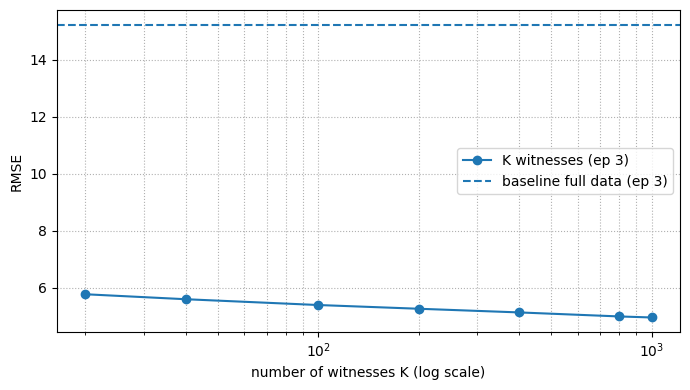

In [ ]:
#Same as above but for MNIST

import gc, math, time, torch, matplotlib.pyplot as plt
from pathlib import Path
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR


for v in list(globals().values()):
    if isinstance(v, torch.nn.Module):
        del v
gc.collect();  torch.cuda.empty_cache()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# editable constants
#finds a trained model in your weights or retrains 
epochs_baseline = 250           
epochs_witness  = 250        # (finds a trained model in your weights or retrains it as above)
witness_grid    = [20,40,100,200,400,800,1000]       
noise_std       = 1.0

CKPT_DIR = Path('new_Stein_models_MNIST')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# DataLoaders (orig settings)
flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])

mnist = torchvision.datasets.MNIST('./data', train=True,
                                   download=True, transform=flat)
data_tensor  = torch.stack([x.to(device) for x, _ in mnist])
label_tensor = torch.tensor([y for _, y in mnist], device=device)
ds_on_dev    = TensorDataset(data_tensor, label_tensor)

n_total = len(ds_on_dev)
n_train = int(0.9 * n_total)
n_test  = n_total - n_train
train_ds, test_ds = random_split(ds_on_dev, [n_train, n_test],
                                 generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=1000,
                          shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=100,
                          shuffle=False, drop_last=False)

train_tensor = torch.stack([d[0] for d in train_ds]).float().to(device)
D = 28 * 28

def train(model, *, epochs, train_witness, tag=''):
    params = (model.parameters() if train_witness else
              [p for n, p in model.named_parameters()
                 if ('t_raw' in n or 'dt_raw' in n)])

    opt  = torch.optim.Adam(params, lr=1e-2, betas=(0.9, 0.9))
    sch  = CosineAnnealingLR(opt, T_max=epochs * len(train_loader),
                             eta_min=1e-4)

    every = max(1, epochs // 5)
    t0_all = time.time()
    for ep in range(epochs):
        run = 0.0
        model.train()
        for clean, _ in train_loader:
            clean = clean.to(device)
            noisy = clean + noise_std * torch.randn_like(clean)
            recon, _ = model(noisy)
            loss = F.mse_loss(recon, clean)

            opt.zero_grad(); loss.backward(); opt.step(); sch.step()
            run += loss.item()

        if (ep + 1) % every == 0 or ep in (0, epochs-1):
            print(f'[{tag}] ep {ep+1:03d}/{epochs}  '
                  f'MSE {run/len(train_loader):.3e}  '
                  f'{(time.time()-t0_all)/60:4.1f} min')

@torch.no_grad()
def rmse(model):
    se, n = 0.0, 0
    model.eval()
    for clean, _ in test_loader:
        clean = clean.to(device)
        noisy = clean + noise_std * torch.randn_like(clean)
        recon, _ = model(noisy)
        se += F.mse_loss(recon, clean, reduction='sum').item()
        n  += clean.size(0)
    return math.sqrt(se / n)

# baseline (K = N)
K_full  = train_tensor.size(0)
base_ck = CKPT_DIR / f'baseline_fullK_ep{epochs_baseline}.pth'

if base_ck.exists():
    print('⤴ loading MNIST baseline …')
    baseline = torch.load(base_ck, map_location=device)
else:
    print('⧗ training MNIST baseline …')
    baseline = SixStepDenoiser_multiple(D=D, K=K_full, H=1,
                                        train_tensor=train_tensor).to(device)
    shared_W = torch.nn.Parameter(train_tensor.half(), requires_grad=False)
    for lyr in baseline.scores:
        lyr[0].W = shared_W
    train(baseline, epochs=epochs_baseline,
          train_witness=False, tag='BASE')
    torch.save(baseline, base_ck)

baseline_rmse = rmse(baseline)
print(f'Baseline RMSE = {baseline_rmse:.4e}')

# witness sweep
rmse_vals = []
for K in witness_grid:
    ck = CKPT_DIR / f'witness_K{K}_ep{epochs_witness}.pth'
    if ck.exists():
        print(f'⤴ loading K={K} …')
        mdl = torch.load(ck, map_location=device)
    else:
        print(f'⧗ training K={K} for {epochs_witness} epochs …')
        mdl = SixStepDenoiser_multiple(D=D, K=K, H=1,
                                       train_tensor=train_tensor).to(device)
        train(mdl, epochs=epochs_witness,
              train_witness=True, tag=f'K={K}')
        torch.save(mdl, ck)

    r = rmse(mdl); rmse_vals.append(r)
    print(f'   ↳ test-set RMSE = {r:.4e}')
    del mdl; gc.collect(); torch.cuda.empty_cache()

# plot
plt.figure(figsize=(7,4))
plt.plot(witness_grid, rmse_vals, marker='o',
         label=f'K witnesses (ep {epochs_witness})')
plt.axhline(baseline_rmse, ls='--',
            label=f'baseline full data (ep {epochs_baseline})')
plt.xscale('log')
plt.xlabel('number of witnesses K (log scale)')
plt.ylabel('RMSE')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()


Files already downloaded and verified
⤴ loading CIFAR‑100 baseline …
Baseline RMSE = 9.7231e+00
⤴ loading K=20 …
   ↳ test-set RMSE = 9.9273e+00
⤴ loading K=40 …
   ↳ test-set RMSE = 9.5565e+00
⤴ loading K=100 …
   ↳ test-set RMSE = 9.1914e+00
⤴ loading K=200 …
   ↳ test-set RMSE = 8.9933e+00
⤴ loading K=400 …
   ↳ test-set RMSE = 8.8242e+00
⤴ loading K=800 …
   ↳ test-set RMSE = 8.6918e+00
⤴ loading K=1000 …
   ↳ test-set RMSE = 8.6519e+00


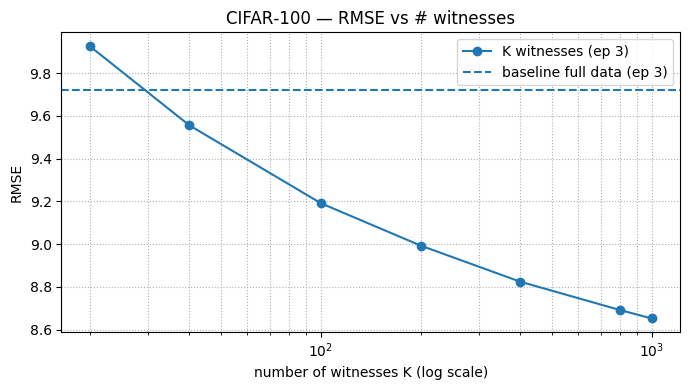

In [ ]:
##RMSE vs # witnesses • CIFAR‑100 • anisotropic models 
#   Prints RMSE for each model and shows the plot
#   Relies on train(), rmse(), SixStepDenoiser_multiple defined earlier


# fresh GPU / RAM state
for v in list(globals().values()):
    if isinstance(v, torch.nn.Module):
        del v
gc.collect(); torch.cuda.empty_cache()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# editable constants (same as CIFAR‑10 cell)
epochs_baseline = 200 
epochs_witness  = 400
witness_grid    = [20, 40, 100, 200, 400, 800, 1000]
noise_std       = 1.0

CKPT_DIR = Path('new_Stein_models_CIFAR100')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# DataLoaders (identical settings, new dataset)
to_flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])

cifar100 = torchvision.datasets.CIFAR100('./data', train=True,
                                         download=True, transform=to_flat)
data_tensor  = torch.stack([x.to(device) for x, _ in cifar100])
label_tensor = torch.tensor([y for _, y in cifar100], device=device)
ds_on_dev    = TensorDataset(data_tensor, label_tensor)

n_total = len(ds_on_dev)
n_train = int(0.9 * n_total)
n_test  = n_total - n_train
train_ds, test_ds = random_split(ds_on_dev, [n_train, n_test],
                                 generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=1000,
                          shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=1000,
                          shuffle=True, drop_last=True)

train_tensor = torch.stack([d[0] for d in train_ds]).float().to(device)
D = 3 * 32 * 32   # 3072 input dims

# baseline (shared‑W, K = N)
K_full  = train_tensor.size(0)
base_ck = CKPT_DIR / f'baseline_fullK_ep{epochs_baseline}.pth'

if base_ck.exists():
    print('⤴ loading CIFAR‑100 baseline …')
    baseline = torch.load(base_ck, map_location=device)
else:
    print('⧗ training CIFAR‑100 baseline …')
    baseline = SixStepDenoiser_multiple(D=D, K=K_full, H=1,
                                        train_tensor=train_tensor,
                                        t_start=10, t_end=1).to(device)
    shared_W = torch.nn.Parameter(train_tensor.half(), requires_grad=False)
    for lyr in baseline.scores:
        lyr[0].W = shared_W                               # single fp16 buffer
    train(baseline, epochs=epochs_baseline,
          train_witness=False, tag='BASE‑C100')
    torch.save(baseline, base_ck)

baseline_rmse = rmse(baseline)
print(f'Baseline RMSE = {baseline_rmse:.4e}')

# witness sweep 
rmse_vals = []
for K in witness_grid:
    ck = CKPT_DIR / f'witness_K{K}_ep{epochs_witness}.pth'
    if ck.exists():
        print(f'⤴ loading K={K} …')
        mdl = torch.load(ck, map_location=device)
    else:
        print(f'⧗ training K={K} for {epochs_witness} epochs …')
        mdl = SixStepDenoiser_multiple(D=D, K=K, H=1,
                                       train_tensor=train_tensor,
                                       t_start=10, t_end=1).to(device)
        train(mdl, epochs=epochs_witness,
              train_witness=True, tag=f'K={K}-C100')
        torch.save(mdl, ck)

    r = rmse(mdl); rmse_vals.append(r)
    print(f'   ↳ test-set RMSE = {r:.4e}')
    del mdl; gc.collect(); torch.cuda.empty_cache()

#  plot 
plt.figure(figsize=(7,4))
plt.plot(witness_grid, rmse_vals, marker='o',
         label=f'K witnesses (ep {epochs_witness})')
plt.axhline(baseline_rmse, ls='--',
            label=f'baseline full data (ep {epochs_baseline})')
plt.xscale('log')
plt.xlabel('number of witnesses K (log scale)')
plt.ylabel('RMSE')
plt.title('CIFAR‑100 — RMSE vs # witnesses')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()



Files already downloaded and verified
Files already downloaded and verified


/tmp/ipykernel_3435314/1739843007.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


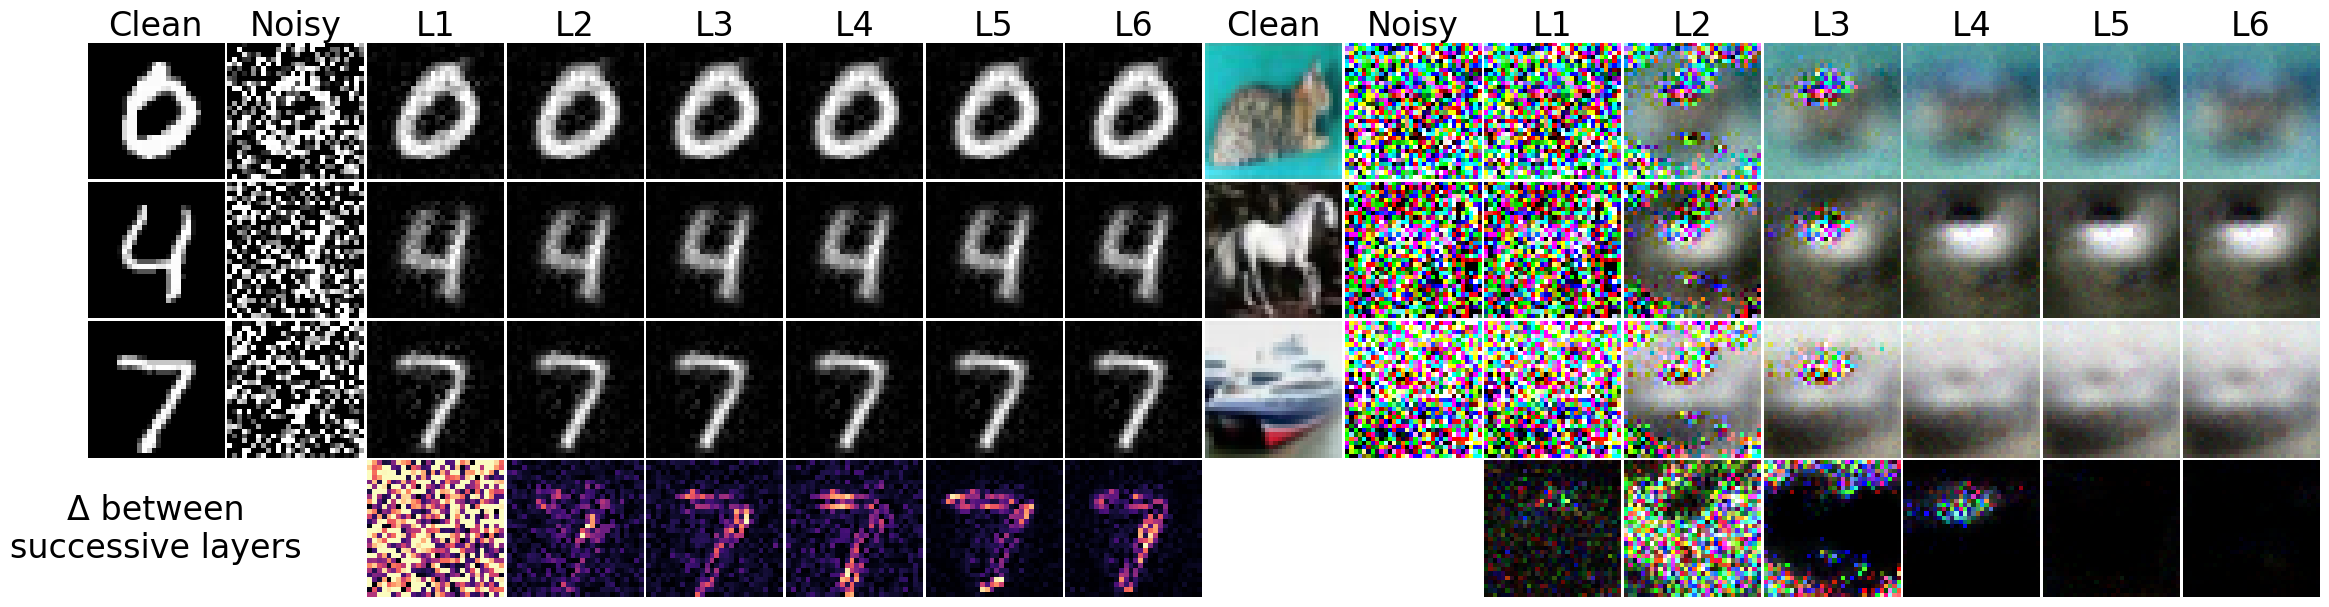

In [ ]:
# Figure 1 in paper 
import gc, torch, torchvision, matplotlib.pyplot as plt
from pathlib import Path

#  checkpoint paths 250
STEIN_MNIST = Path('new_Stein_models_MNIST/witness_K1000_ep3.pth')
STEIN_CIFAR = Path('new_Stein_models_CIFAR10/witness_K1000_ep3.pth')


device = 'cuda' if torch.cuda.is_available() else 'cpu'
CAT_OCCURRENCE = 16          # pick a specific cat image that's nice
torch.manual_seed(0)

#  data helpers
to_flat = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Lambda(lambda x: x.view(-1))
])
def load_ds(name, *, train=False):
    if name == 'mnist':
        return torchvision.datasets.MNIST('./data', train=train,
                                          download=True, transform=to_flat), (1, 28, 28)
    return torchvision.datasets.CIFAR10('./data', train=train,
                                        download=True, transform=to_flat), (3, 32, 32)
def nth_index(ds, lbl, nth=0):
    k = -1
    for i, (_, y) in enumerate(ds):
        if y == lbl:
            k += 1
            if k == nth:
                return i
    raise ValueError
def fixed_indices(cat_occ):
    mn, _ = load_ds('mnist')
    cf, _ = load_ds('cifar')
    idx_m = [nth_index(mn, d, 0) for d in (0, 4, 7)]
    idx_c = [nth_index(cf, 3, cat_occ),
             nth_index(cf, 7, 0),
             nth_index(cf, 8, 0)]
    return idx_m, idx_c
IDX_M, IDX_C = fixed_indices(CAT_OCCURRENCE)

@torch.no_grad()
def rows_and_delta(model, ds, shp, idx, σ=1.0):
    rows = []
    for i in idx:
        clean = ds[i][0].to(device)
        noisy = clean + σ * torch.randn_like(clean)
        _, traj = model(noisy.unsqueeze(0))            # traj[0] is input
        traj = [noisy.cpu()] + [t.squeeze().cpu() for t in traj[1:]]
        rows.append([clean.cpu(), *traj])
    Δ = [torch.abs(traj[j] - traj[j-1]) for j in range(1, 7)]
    return rows, Δ

def im(ax, img, shp, cmap=None):
    C, H, W = shp
    if C == 1:
        ax.imshow(img.view(H, W).clamp(0, 1), cmap=cmap or 'gray')
    else:
        ax.imshow(img.view(C, H, W).permute(1, 2, 0).clamp(0, 1), cmap=cmap)
    ax.axis('off')

def stein_grid():
    mdl_m = torch.load(STEIN_MNIST, map_location=device).eval()
    mdl_c = torch.load(STEIN_CIFAR, map_location=device).eval()

    ds_m, shp_m = load_ds('mnist')
    ds_c, shp_c = load_ds('cifar')

    Rm, Δm = rows_and_delta(mdl_m, ds_m, shp_m, IDX_M)
    Rc, Δc = rows_and_delta(mdl_c, ds_c, shp_c, IDX_C)

    rows, cols = 3, 8
    tot = cols * 2
    fig, ax = plt.subplots(rows + 1, tot,
                           figsize=(tot * 1.8, (rows + 1) * 1.8),
                           gridspec_kw=dict(wspace=0.02, hspace=0.02))
    if rows == 1:
        ax = ax[None, :]   # ensure 2-D axis array

    titles = ['Clean', 'Noisy'] + [f'L{i}' for i in range(1, 7)]

    # — MNIST block —
    for r, row in enumerate(Rm):
        for c, img in enumerate(row):
            im(ax[r, c], img, shp_m)
            if r == 0:
                ax[r, c].set_title(titles[c], fontsize=24, pad=2)

    # — CIFAR block —
    for r, row in enumerate(Rc):
        for c, img in enumerate(row):
            im(ax[r, c + cols], img, shp_c)
            if r == 0:
                ax[r, c + cols].set_title(titles[c], fontsize=24, pad=2)

    # — bottom Δ-row (index = rows) —
    for c in range(tot):
        ax[rows, c].axis('off')
    for j, img in enumerate(Δm):
        im(ax[rows, j + 2], img, shp_m, cmap='magma')
    for j, img in enumerate(Δc):
        im(ax[rows, cols + j + 2], img, shp_c, cmap='magma')

    ax[rows, 0].text(0.5, 0.5, 'Δ between\nsuccessive layers',
                     ha='center', va='center', fontsize=24)
    ax[rows, 1].axis('off')

 
    plt.tight_layout()
    plt.show()
    gc.collect(); torch.cuda.empty_cache()

stein_grid()


In [3]:
# =====================================================================
# [PARAMETER COUNT CELL] – trainable parameters for every variant here
#
# • Uses the same logic as the training code to decide which tensors
#   the optimiser sees.
# • Covers baseline + witness grids for CIFAR‑10, MNIST, and CIFAR‑100.
# =====================================================================
import torch, pandas as pd

def count_schedule_only(m):
    """Parameters actually given to the optimiser in baseline mode."""
    return sum(p.numel() for n, p in m.named_parameters()
                         if ('t_raw' in n or 'dt_raw' in n))

def count_all(m):
    """All parameters with requires_grad=True (witness mode)."""
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ---------------------------------------------------------------------
#  constants
# ---------------------------------------------------------------------
L, H = 6, 1
D_MNIST   = 28 * 28
D_CIFAR   = 3 * 32 * 32
datasets  = [
    ("MNIST"   , D_MNIST  , [20, 40, 100, 200, 400, 800, 1000]),
    ("CIFAR‑10", D_CIFAR  , [20, 40, 100, 200, 400, 800, 1000]),
    ("CIFAR‑100", D_CIFAR , [20, 40, 100, 200, 400, 800, 1000]),
]

results = []

for ds_name, D, Ks in datasets:
    # ---- baseline (schedule‑only) -----------------------------------
    dummy = torch.zeros(1, D)                           # 1×D tensor
    base  = SixStepDenoiser_multiple(D=D, K=1, H=H,
                                     train_tensor=dummy,
                                     t_start=1.0, t_end=0.1)
    params = count_schedule_only(base)                  # 12 scalars
    results.append(dict(dataset=ds_name,
                        model="baseline‑sharedW",
                        K="—",
                        params=params))

    # ---- witness grid ----------------------------------------------
    for K in Ks:
        dummy = torch.zeros(max(K, 1), D)
        mdl   = SixStepDenoiser_multiple(D=D, K=K, H=H,
                                         train_tensor=dummy,
                                         t_start=1.0, t_end=0.1)
        params = count_all(mdl)
        results.append(dict(dataset=ds_name,
                            model="witness",
                            K=K,
                            params=params))

# ---------------------------------------------------------------------
#  tidy table
# ---------------------------------------------------------------------
df = pd.DataFrame(results)
df["params(M)"] = (df["params"] / 1_000_000).round(3)

print("\n🧮  Trainable‑parameter counts\n")
print(df[["dataset", "model", "K", "params", "params(M)"]]
        .sort_values(["dataset", "model", "K"])
        .to_string(index=False))



🧮  Trainable‑parameter counts

  dataset            model    K   params  params(M)
 CIFAR‑10 baseline‑sharedW    —       12      0.000
 CIFAR‑10          witness   20   405516      0.406
 CIFAR‑10          witness   40   774156      0.774
 CIFAR‑10          witness  100  1880076      1.880
 CIFAR‑10          witness  200  3723276      3.723
 CIFAR‑10          witness  400  7409676      7.410
 CIFAR‑10          witness  800 14782476     14.782
 CIFAR‑10          witness 1000 18468876     18.469
CIFAR‑100 baseline‑sharedW    —       12      0.000
CIFAR‑100          witness   20   405516      0.406
CIFAR‑100          witness   40   774156      0.774
CIFAR‑100          witness  100  1880076      1.880
CIFAR‑100          witness  200  3723276      3.723
CIFAR‑100          witness  400  7409676      7.410
CIFAR‑100          witness  800 14782476     14.782
CIFAR‑100          witness 1000 18468876     18.469
    MNIST baseline‑sharedW    —       12      0.000
    MNIST          witness   20 